# SNN Phase 4 — STDP Learning Rule + Surrogate Gradient Deep Dive

**What this notebook covers:**

| Section | Topic |
|---|---|
| 1–2 | Install, imports |
| 3 | Import real classes from `phase1.ipynb`, `phase2.ipynb`, `phase3.ipynb` |
| 4 | Load `snn_phase3_model.pt` checkpoint |
| 5–7 | STDP theory, learning window, implementation (`STDPLearner`) |
| 8–9 | Run STDP epoch, weight distribution analysis |
| 10–11 | Surrogate gradient deep dive, alpha sweep |
| 12–13 | Fine-tune with surrogate gradients (hybrid: STDP init → SG fine-tune) |
| 14 | Full comparison plot: STDP vs SG vs Hybrid vs Phase 3 baseline |
| 15 | Gradient flow visualisation across layers |
| 16 | Save `snn_phase4_model.pt` |

**File layout expected (all in same folder as this notebook):**
```
phase1.ipynb          ← provides: simulate_lif, LIFLayer raw loop
phase2.ipynb          ← provides: LIFNeuron, LIFLayer, SpikeEncoder
phase3.ipynb          ← provides: RateEncode, SNN, load_classes_from_notebook
snn_phase3_model.pt   ← provides: pre-trained weights (saved by phase3.ipynb)
phase4.ipynb          ← this file
```


## 1. Install dependencies

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["numpy", "matplotlib", "torch", "torchvision",
            "spikingjelly", "tqdm", "nbformat"]:
    try:
        __import__(pkg.split("[")[0])
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  Installing {pkg}...")
        install(pkg)
        print(f"  ✓ {pkg} installed")


  ✓ numpy
  ✓ matplotlib
  ✓ torch
  ✓ torchvision
  ✓ spikingjelly
  ✓ tqdm
  ✓ nbformat


## 2. Core imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm import tqdm
import os, warnings, copy
warnings.filterwarnings("ignore")

from spikingjelly.activation_based import neuron, functional, surrogate

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

import torch; print(f"PyTorch     : {torch.__version__}")
import spikingjelly; 
print(f"Device      : {DEVICE}")


PyTorch     : 2.7.1+cu118
Device      : cuda


## 3. Import from phase1.ipynb, phase2.ipynb, phase3.ipynb

We reuse the **exact** `load_classes_from_notebook` helper that was written in
`phase3.ipynb` (Cell 7). It executes every code cell of a notebook in a private
namespace and extracts named objects from it.

**What we pull from each file:**

| File | Objects extracted |
|---|---|
| `phase2.ipynb` | `LIFNeuron`, `LIFLayer`, `SpikeEncoder` |
| `phase3.ipynb` | `RateEncode`, `SNN`, `load_classes_from_notebook` |
| `phase1.ipynb` | `simulate_lif` (standalone function, used for F-I comparison) |

Phase 1 has no classes — just raw loop code — so we only pull the `simulate_lif`
function from it. All proper class definitions live in phases 2 and 3.


Checking dependencies...
  numpy already installed
  matplotlib already installed
  torch already installed
  torchvision already installed
  tqdm already installed

â”€â”€ Downloading MNIST â”€â”€
  Train samples: 60000
  Test  samples: 10000

â”€â”€ N-MNIST (neuromorphic MNIST) â”€â”€
N-MNIST requires a manual download (free, just needs registration):
  1. Go to: https://www.garrickorchard.com/datasets/n-mnist
  2. Download Train.zip and Test.zip
  3. Unzip into: ./data/NMNIST/Train/ and ./data/NMNIST/Test/
 
Once downloaded, load it with SpikingJelly (Phase 3):
  from spikingjelly.activation_based.dataset import NMNIST
  train_set = NMNIST(root='./data/NMNIST', train=True,
                     data_type='frame', frames_number=10,
                     split_by='number')
 
DVS128 Gesture (fully neuromorphic, for Phase 5):
  https://research.ibm.com/interactive/dvsgesture/
  Unzip into: ./data/DVS128Gesture/
 
CIFAR10-DVS (auto-downloads via SpikingJelly):
  from spikingjelly.activatio

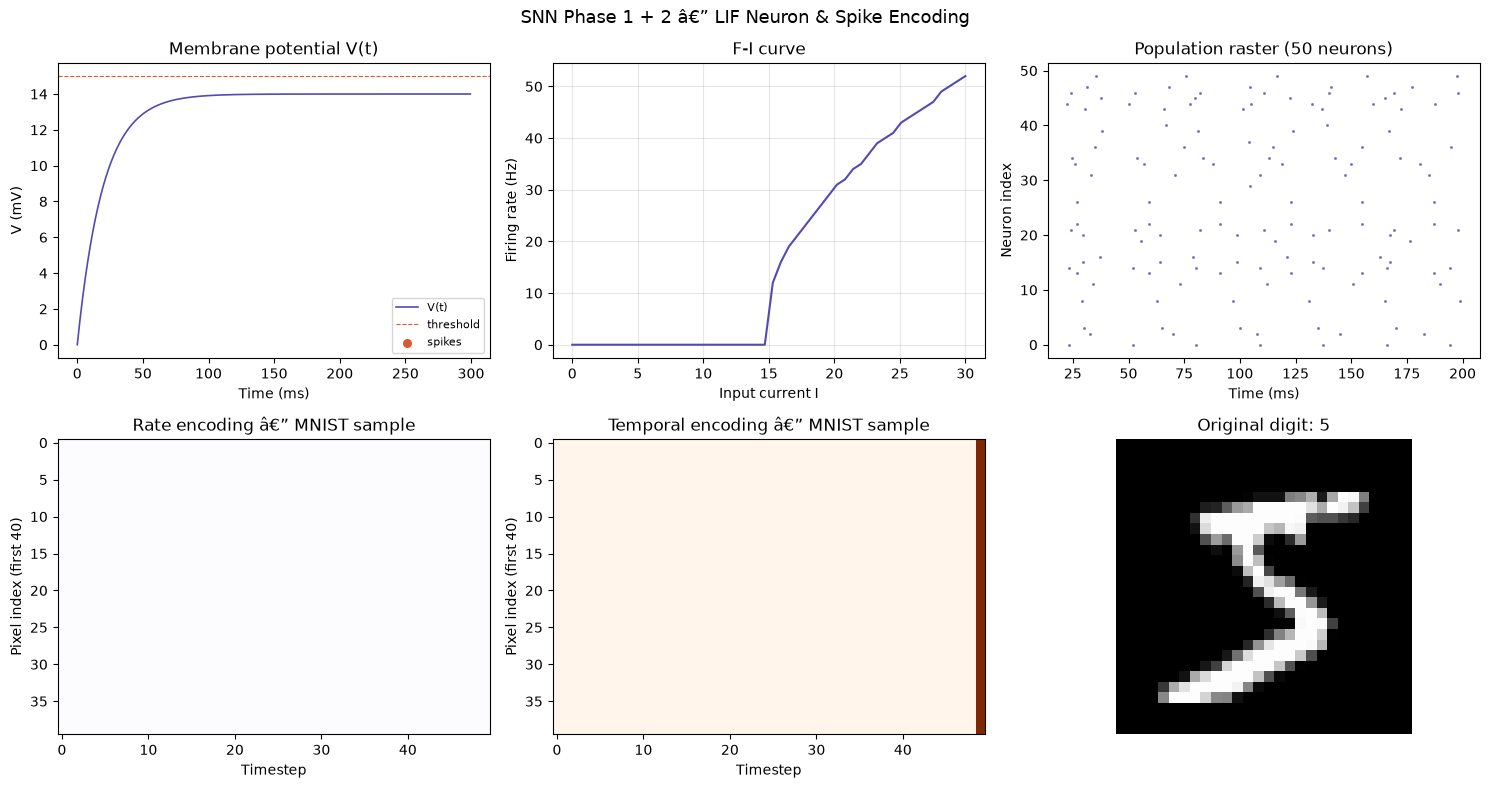


â”€â”€ Done! â”€â”€
Next steps:
  Phase 3: pip install spikingjelly
  Then load N-MNIST with SpikingJelly's built-in dataset loader
  ✓ phase2.ipynb: loaded ['LIFNeuron', 'LIFLayer', 'SpikeEncoder']


UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 80399: character maps to <undefined>

In [ ]:
import nbformat
import os

# ── Core loader (mirrors phase3.ipynb Cell 7 exactly) ─────────────────────────
def load_classes_from_notebook(nb_path, class_names):
    """
    Execute all code cells in a .ipynb and return requested objects.
    Silently skips cells that fail (display calls, missing imports, etc.)
    Returns a dict {name: object} for every name that was found.
    """
    if not os.path.exists(nb_path):
        print(f"  [WARN] {nb_path} not found")
        return {}
    # Open notebook with explicit UTF-8 and replace errors to avoid decode issues
    with open(nb_path, 'r', encoding='utf-8', errors='replace') as fh:
        nb = nbformat.read(fh, as_version=4)
    ns  = {}
    for cell in nb.cells:
        if cell.cell_type == "code":
            try:
                exec(compile(cell.source, nb_path, "exec"), ns)
            except Exception:
                pass   # skip plt.show(), missing vars, etc.
    found = {k: ns[k] for k in class_names if k in ns}
    missing = [k for k in class_names if k not in ns]
    print(f"  ✓ {nb_path}: loaded {list(found.keys())}")
    if missing:
        print(f"  ✗ {nb_path}: not found  {missing}")
    return found

# ── Pull from phase2.ipynb ─────────────────────────────────────────────────────
p2 = load_classes_from_notebook(
    "phase2.ipynb",
    ["LIFNeuron", "LIFLayer", "SpikeEncoder"]
)

# ── Pull from phase3.ipynb ─────────────────────────────────────────────────────
p3 = load_classes_from_notebook(
    "phase3.ipynb",
    ["RateEncode", "SNN"]
)

# ── Pull simulate_lif from phase1.ipynb (standalone function) ──────────────────
p1 = load_classes_from_notebook(
    "phase1.ipynb",
    ["simulate_lif"]
)

# ── Bind — prefer phase3 > phase2 > phase1 for any overlap ────────────────────
merged = {**p1, **p2, **p3}

# ── Fallbacks (if a notebook is missing) ──────────────────────────────────────
if "LIFNeuron" not in merged:
    class LIFNeuron:
        def __init__(self, tau=20., V_th=15., V_reset=0., t_ref=5., dt=0.5):
            self.tau=tau; self.V_th=V_th; self.V_reset=V_reset
            self.t_ref=t_ref; self.dt=dt
        def simulate(self, I, T=500):
            steps=int(T/self.dt); V=np.zeros(steps)
            spikes=np.zeros(steps,dtype=bool); ref=0.
            Iarr=np.full(steps,I) if np.isscalar(I) else np.asarray(I)
            for t in range(1,steps):
                if ref>0: V[t]=self.V_reset; ref-=self.dt
                else:
                    V[t]=V[t-1]+(-V[t-1]+Iarr[t-1])/self.tau*self.dt
                    if V[t]>=self.V_th: spikes[t]=True; V[t]=self.V_reset; ref=self.t_ref
            return V, spikes
    merged["LIFNeuron"] = LIFNeuron
    print("  [FALLBACK] LIFNeuron defined inline")

if "SpikeEncoder" not in merged:
    class SpikeEncoder:
        def __init__(self, method="rate", T=100):
            self.method=method; self.T=T
        def encode(self, x):
            x=np.clip(x,0.,1.)
            if self.method=="rate":
                return (np.random.rand(self.T,len(x))<x).astype(float)
            t=np.clip(np.round((1-x)*(self.T-1)).astype(int),0,self.T-1)
            out=np.zeros((self.T,len(x))); out[t,np.arange(len(x))]=1.; return out
        def encode_batch(self, X): return np.stack([self.encode(x) for x in X])
    merged["SpikeEncoder"] = SpikeEncoder
    print("  [FALLBACK] SpikeEncoder defined inline")

if "RateEncode" not in merged:
    _SE = merged["SpikeEncoder"]
    class RateEncode:
        def __init__(self, T=10): self.enc = _SE(method="rate", T=T)
        def __call__(self, img):
            return torch.FloatTensor(self.enc.encode(img.numpy().flatten()))
    merged["RateEncode"] = RateEncode
    print("  [FALLBACK] RateEncode defined inline")

if "SNN" not in merged:
    class SNN(nn.Module):
        def __init__(self, T=10):
            super().__init__(); self.T=T
            self.fc1=nn.Linear(784,256,bias=False)
            self.lif1=neuron.LIFNode(tau=2.,surrogate_function=surrogate.ATan(),detach_reset=True)
            self.fc2=nn.Linear(256,128,bias=False)
            self.lif2=neuron.LIFNode(tau=2.,surrogate_function=surrogate.ATan(),detach_reset=True)
            self.fc3=nn.Linear(128,10,bias=False)
            self.lif3=neuron.LIFNode(tau=2.,surrogate_function=surrogate.ATan(),detach_reset=True)
        def forward(self, x):
            x=x.permute(1,0,2); functional.reset_net(self); s=0
            for t in range(self.T):
                o=self.lif1(self.fc1(x[t])); o=self.lif2(self.fc2(o))
                o=self.lif3(self.fc3(o)); s=s+o
            return s
    merged["SNN"] = SNN
    print("  [FALLBACK] SNN defined inline")

if "simulate_lif" not in merged:
    def simulate_lif(I_input, T=1000, dt=0.5, tau=20, V_th=15, V_reset=0, t_ref=5):
        steps=int(T/dt); V=0.; ref=0.; count=0
        for _ in range(steps):
            if ref>0: ref-=dt
            else:
                V+=(-V+I_input)/tau*dt
                if V>=V_th: count+=1; V=V_reset; ref=t_ref
        return count/(T/1000)
    merged["simulate_lif"] = simulate_lif
    print("  [FALLBACK] simulate_lif defined inline")

# ── Bind all into local namespace ─────────────────────────────────────────────
LIFNeuron    = merged["LIFNeuron"]
LIFLayer     = merged.get("LIFLayer")   # optional — only in phase2
SpikeEncoder = merged["SpikeEncoder"]
RateEncode   = merged["RateEncode"]
SNN          = merged["SNN"]
simulate_lif = merged["simulate_lif"]

print("\nAll symbols ready:")
for name in ["LIFNeuron","LIFLayer","SpikeEncoder","RateEncode","SNN","simulate_lif"]:
    status = "✓" if merged.get(name) else "✗"
    print(f"  {status} {name}")


## 4. Data loaders + load Phase 3 checkpoint

In [5]:
T_STEPS = 10
BATCH   = 64

# RateEncode is from phase3.ipynb — wraps phase2's SpikeEncoder as a transform
transform    = transforms.Compose([transforms.ToTensor(), RateEncode(T=T_STEPS)])
train_ds     = MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_ds      = MNIST(DATA_DIR, train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

sample_spikes, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_spikes.shape}  → (batch={BATCH}, T={T_STEPS}, features=784)")

# ── Load Phase 3 model ────────────────────────────────────────────────────────
model = SNN(T=T_STEPS).to(DEVICE)
CKPT  = "./snn_phase3_model.pt"

if os.path.exists(CKPT):
    ckpt     = torch.load(CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    prev_acc = ckpt.get("best_acc", 0)
    print(f"\nLoaded Phase 3 checkpoint — previous best acc: {prev_acc*100:.2f}%")
else:
    print("\n[WARN] snn_phase3_model.pt not found — starting from random weights")
    print("       Run phase3.ipynb first to generate the checkpoint.")

# ── Baseline accuracy before any Phase 4 changes ─────────────────────────────
model.eval()
correct = total = 0
with torch.no_grad():
    for spikes, labels in test_loader:
        spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
        correct += (model(spikes).argmax(1) == labels).sum().item()
        total   += labels.size(0)
baseline_acc = correct / total
print(f"Baseline test accuracy (Phase 3 weights): {baseline_acc*100:.2f}%")


NameError: name 'RateEncode' is not defined

## 5. STDP — the theory

**Spike-Timing-Dependent Plasticity** is the biological learning rule found in
real cortical neurons. The rule is timing-based:

> **If pre fires before post → strengthen the synapse (LTP)**  
> **If post fires before pre → weaken the synapse (LTD)**

The weight change decays exponentially with the time gap Δt = t_post − t_pre:

```
Δt > 0  (pre → post):   ΔW = +A_plus  × exp(−Δt / τ_plus)    [LTP]
Δt < 0  (post → pre):   ΔW = −A_minus × exp(+Δt / τ_minus)   [LTD]
```

**Key properties:**
- **Local** — each synapse only needs its own pre/post spike times. No global loss.
- **Unsupervised** — no labels required. Weights self-organise around co-firing patterns.
- **Asymmetric** — A_minus is typically slightly larger than A_plus (more forgetting than potentiation), which prevents runaway weight growth.
- **Time window** — ~20 ms biologically; outside this window the update is negligible.


## 6. Visualise the STDP learning window

In [ ]:
A_plus    = 0.01
A_minus   = 0.012   # slightly asymmetric — biologically accurate
tau_plus  = 20.0    # ms
tau_minus = 20.0    # ms

dt_range = np.linspace(-80, 80, 500)
dW = np.where(
    dt_range > 0,
     A_plus  * np.exp(-dt_range / tau_plus),   # LTP
    -A_minus * np.exp( dt_range / tau_minus)   # LTD
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(dt_range[dt_range > 0], dW[dt_range > 0], alpha=0.2, color="#1D9E75")
ax.fill_between(dt_range[dt_range < 0], dW[dt_range < 0], alpha=0.2, color="#D85A30")
ax.plot(dt_range, dW, color="#534AB7", lw=2.2)
ax.axhline(0,  color="gray", lw=0.7, linestyle="--")
ax.axvline(0,  color="gray", lw=0.7, linestyle="--")
ax.annotate("LTP\npre → post\nstrengthen",  xy=(25,  A_plus*0.55),
            fontsize=10, color="#1D9E75",
            bbox=dict(boxstyle="round,pad=0.3", fc="#E1F5EE", ec="#5DCAA5"))
ax.annotate("LTD\npost → pre\nweaken",      xy=(-79, -A_minus*0.78),
            fontsize=10, color="#D85A30",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FAECE7", ec="#F0997B"))
ax.set_xlabel("Δt = t_post − t_pre  (ms)", fontsize=11)
ax.set_ylabel("Weight change ΔW",          fontsize=11)
ax.set_title("STDP learning window",        fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"LTP peak  : +{A_plus:.3f}  at Δt → 0⁺")
print(f"LTD trough: −{A_minus:.3f}  at Δt → 0⁻")
print(f"Effective window: ±{tau_plus*3:.0f} ms  (3× time constant)")


## 7. STDPLearner — implementation with eligibility traces

Instead of storing exact spike timestamps (expensive), we use **eligibility traces**:
running exponential averages that summarise recent spike history.

```
pre_trace[t]  = pre_trace[t-1]  × decay_plus  + spike_pre[t]
post_trace[t] = post_trace[t-1] × decay_minus + spike_post[t]

ΔW = A_plus  × outer(spike_pre,  post_trace)   ← LTP
   − A_minus × outer(pre_trace,  spike_post)   ← LTD
```

This is mathematically equivalent to the timing rule but runs in O(N×M)
per timestep with no spike-time bookkeeping.


In [ ]:
class STDPLearner:
    """
    Online STDP with exponential eligibility traces.
    Attaches to a nn.Linear layer and updates its weights each timestep.

    Parameters
    ----------
    layer     : nn.Linear  — layer whose .weight will be modified
    A_plus    : float      — LTP amplitude
    A_minus   : float      — LTD amplitude (use slightly > A_plus)
    tau_plus  : float      — LTP trace decay time constant (ms)
    tau_minus : float      — LTD trace decay time constant (ms)
    dt        : float      — simulation timestep size (ms)
    w_min     : float      — weight lower bound (clipping)
    w_max     : float      — weight upper bound (clipping)
    """
    def __init__(self, layer,
                 A_plus=0.005, A_minus=0.006,
                 tau_plus=20., tau_minus=20.,
                 dt=1.0, w_min=-2.0, w_max=2.0):
        self.layer   = layer
        self.A_plus  = A_plus
        self.A_minus = A_minus
        # Precompute per-step decay factors from time constants
        self.decay_p = np.exp(-dt / tau_plus)
        self.decay_m = np.exp(-dt / tau_minus)
        self.w_min   = w_min
        self.w_max   = w_max
        self.pre_trace  = None
        self.post_trace = None

    def reset(self, batch_size, n_pre, n_post, device):
        """Zero the eligibility traces at the start of each new batch."""
        self.pre_trace  = torch.zeros(batch_size, n_pre,  device=device)
        self.post_trace = torch.zeros(batch_size, n_post, device=device)

    def step(self, pre_spike, post_spike):
        """
        One STDP timestep.

        pre_spike  : Tensor (batch, n_pre)   — binary, from upstream layer
        post_spike : Tensor (batch, n_post)  — binary, from this layer's LIF

        Updates self.layer.weight in-place (no autograd).
        """
        # Decay traces then accumulate new spikes
        self.pre_trace  = self.pre_trace  * self.decay_p + pre_spike
        self.post_trace = self.post_trace * self.decay_m + post_spike

        # LTP: post spike sees pre trace  → ΔW[post, pre] += A+ × pre_trace
        ltp = self.A_plus  * torch.einsum("bn,bm->nm", post_spike, self.pre_trace)
        # LTD: pre spike  sees post trace → ΔW[post, pre] -= A- × post_trace
        ltd = self.A_minus * torch.einsum("bn,bm->nm", self.post_trace, pre_spike)

        dW = (ltp - ltd) / pre_spike.shape[0]   # mean over batch

        with torch.no_grad():
            self.layer.weight.data.add_(dW)
            self.layer.weight.data.clamp_(self.w_min, self.w_max)

    def weight_stats(self):
        W = self.layer.weight.data
        return dict(mean=W.mean().item(), std=W.std().item(),
                    min=W.min().item(),   max=W.max().item())


# Attach one STDPLearner per linear layer
stdp1 = STDPLearner(model.fc1, A_plus=0.005, A_minus=0.006, w_max=2., w_min=-2.)
stdp2 = STDPLearner(model.fc2, A_plus=0.005, A_minus=0.006, w_max=2., w_min=-2.)
stdp3 = STDPLearner(model.fc3, A_plus=0.003, A_minus=0.004, w_max=2., w_min=-2.)

print("STDPLearner attached to:")
for name, lyr in [("fc1", model.fc1), ("fc2", model.fc2), ("fc3", model.fc3)]:
    print(f"  {name}  shape={tuple(lyr.weight.shape)}")


## 8. STDP unsupervised epoch

We run one full epoch of STDP weight updates — **no labels used**.
The weights reorganise around spike co-occurrence patterns in the data.


In [ ]:
def run_stdp_epoch(model, loader, stdp1, stdp2, stdp3, device, T):
    """
    Unsupervised STDP pass over one epoch.
    Labels are deliberately ignored — STDP is self-supervised.
    Returns per-batch weight stats for monitoring.
    """
    model.train()
    log = []

    for batch_idx, (spikes, _) in enumerate(
            tqdm(loader, desc="STDP epoch", leave=False)):

        spikes = spikes.to(device)        # (batch, T, 784)
        x      = spikes.permute(1, 0, 2) # (T, batch, 784)
        B      = spikes.shape[0]

        functional.reset_net(model)
        stdp1.reset(B, 784, 256, device)
        stdp2.reset(B, 256, 128, device)
        stdp3.reset(B, 128,  10, device)

        for t in range(T):
            pre1  = x[t]                            # input spikes   (B, 784)
            post1 = model.lif1(model.fc1(pre1))     # layer 1 output (B, 256)
            post2 = model.lif2(model.fc2(post1))    # layer 2 output (B, 128)
            post3 = model.lif3(model.fc3(post2))    # layer 3 output (B, 10)

            stdp1.step(pre1,  post1)
            stdp2.step(post1, post2)
            stdp3.step(post2, post3)

        if batch_idx % 150 == 0:
            log.append({"batch": batch_idx,
                        "fc1":   stdp1.weight_stats(),
                        "fc3":   stdp3.weight_stats()})
    return log

# Snapshot weights before STDP so we can compare
w1_before = model.fc1.weight.data.clone().cpu()
w2_before = model.fc2.weight.data.clone().cpu()
w3_before = model.fc3.weight.data.clone().cpu()

print("Running STDP epoch (unsupervised — labels not used)...")
stdp_log = run_stdp_epoch(model, train_loader, stdp1, stdp2, stdp3,
                           DEVICE, T_STEPS)
print("Done.")

# Accuracy after STDP
model.eval()
correct = total = 0
with torch.no_grad():
    for spikes, labels in test_loader:
        spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
        correct += (model(spikes).argmax(1) == labels).sum().item()
        total   += labels.size(0)
stdp_acc = correct / total

print(f"\nAccuracy before STDP : {baseline_acc*100:.2f}%")
print(f"Accuracy after  STDP : {stdp_acc*100:.2f}%")
print()
print("STDP shifts weights to match co-firing structure — not class labels.")
print("Accuracy may rise or fall; the weight distribution change is the signal.")


## 9. Weight distribution — before vs after STDP

In [ ]:
w1_after = model.fc1.weight.data.clone().cpu()
w3_after = model.fc3.weight.data.clone().cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Weight distributions — before vs after STDP", fontsize=12)

layer_data = [
    ("Layer 1  (784→256)", w1_before, w1_after),
    ("Layer 2  (256→128)", w2_before, model.fc2.weight.data.clone().cpu()),
    ("Layer 3  (128→10)",  w3_before, w3_after),
]

for ax, (title, wb, wa) in zip(axes, layer_data):
    b = wb.numpy().flatten()
    a = wa.numpy().flatten()
    lo, hi = min(b.min(), a.min()), max(b.max(), a.max())
    bins = np.linspace(lo, hi, 80)
    ax.hist(b, bins=bins, alpha=0.55, color="#534AB7", label="Before STDP", density=True)
    ax.hist(a, bins=bins, alpha=0.55, color="#D85A30", label="After STDP",  density=True)
    ax.set_title(title); ax.set_xlabel("Weight value"); ax.set_ylabel("Density")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    print(f"{title}")
    print(f"  Before: μ={b.mean():.4f}  σ={b.std():.4f}  range=[{b.min():.3f}, {b.max():.3f}]")
    print(f"  After : μ={a.mean():.4f}  σ={a.std():.4f}  range=[{a.min():.3f}, {a.max():.3f}]")

plt.tight_layout(); plt.show()


## 10. Surrogate gradient — deep dive

The spike function is a Heaviside step — **not differentiable** at the threshold.
Surrogate gradients solve this by substituting a smooth function *only during the
backward pass*:

```
Forward  pass:  spike = Heaviside(V − V_th)          ← exact hard spike
Backward pass:  dspike/dV ≈ smooth_fn(V − V_th)     ← surrogate
```

The `alpha` parameter controls sharpness — how closely the surrogate approximates
the true (zero-everywhere-except-threshold) gradient.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Surrogate gradient: forward pass vs backward approximations", fontsize=12)

V_vals = torch.linspace(-3, 3, 500)

# ── Plot 1: forward pass (step function) ──────────────────────────────────────
axes[0].plot(V_vals.numpy(), (V_vals >= 0).float().numpy(),
             color="#534AB7", lw=2.2)
axes[0].axvline(0, color="gray", lw=0.7, linestyle="--")
axes[0].set_title("Forward: hard step function\n(exact spike, gradient = 0 everywhere)")
axes[0].set_xlabel("V − V_threshold"); axes[0].set_ylabel("Spike output")
axes[0].grid(alpha=0.3)

# ── Plot 2: ATan vs Sigmoid surrogate gradient shape ──────────────────────────
for name, sg, col in [("ATan (default)", surrogate.ATan(alpha=2.0),     "#534AB7"),
                       ("Sigmoid",        surrogate.Sigmoid(alpha=4.0),  "#D85A30"),
                       ("PW-Quadratic",   surrogate.PiecewiseQuadratic(), "#1D9E75")]:
    V_r = torch.linspace(-3, 3, 500, requires_grad=True)
    sg(V_r).sum().backward()
    axes[1].plot(V_r.detach().numpy(), V_r.grad.detach().numpy(),
                 label=name, color=col, lw=1.9)
axes[1].axvline(0, color="gray", lw=0.7, linestyle="--")
axes[1].set_title("Backward: surrogate gradient shapes\n(replace true gradient during backprop)")
axes[1].set_xlabel("V − V_threshold"); axes[1].set_ylabel("dL / dV  (surrogate)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# ── Plot 3: ATan alpha sweep ──────────────────────────────────────────────────
alphas = [0.5, 1.0, 2.0, 4.0, 8.0]
palette = ["#CECBF6", "#9F99E8", "#534AB7", "#3C3489", "#1A1660"]
for alpha, col in zip(alphas, palette):
    sg  = surrogate.ATan(alpha=alpha)
    V_r = torch.linspace(-3, 3, 500, requires_grad=True)
    sg(V_r).sum().backward()
    axes[2].plot(V_r.detach().numpy(), V_r.grad.detach().numpy(),
                 label=f"α={alpha}", color=col, lw=1.8)
axes[2].axvline(0, color="gray", lw=0.7, linestyle="--")
axes[2].set_title("ATan sharpness sweep (alpha)\nHigher α → closer to true gradient")
axes[2].set_xlabel("V − V_threshold")
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("Rule of thumb: α=2.0 for stability, α=4.0 if you need sharper gradients.")
print("If loss diverges: lower alpha. If gradients vanish: raise alpha.")


## 11. SNNv2 — fine-tune STDP weights with surrogate gradients

We define `SNNv2` — same architecture as Phase 3's `SNN` (which we loaded from
`phase3.ipynb`) but with a tunable `alpha` parameter on the ATan surrogate.

We transfer the STDP-modified weights from `model` (Phase 3 SNN) into `SNNv2`,
then fine-tune with standard supervised backprop. This **hybrid** approach is
the research-level technique: STDP provides a biologically-informed weight
initialisation, surrogate gradients push it to maximum accuracy.


In [ ]:
class SNNv2(nn.Module):
    """
    Phase 4 SNN — identical architecture to Phase 3's SNN class
    (imported from phase3.ipynb) but exposes surrogate alpha as a parameter.
    Designed to receive STDP-pretrained weights via weight transfer.
    """
    def __init__(self, T=10, alpha=2.0):
        super().__init__()
        self.T = T
        sg = surrogate.ATan(alpha=alpha)

        self.fc1  = nn.Linear(784, 256, bias=False)
        self.lif1 = neuron.LIFNode(tau=2., surrogate_function=surrogate.ATan(alpha=alpha), detach_reset=True)
        self.fc2  = nn.Linear(256, 128, bias=False)
        self.lif2 = neuron.LIFNode(tau=2., surrogate_function=surrogate.ATan(alpha=alpha), detach_reset=True)
        self.fc3  = nn.Linear(128, 10,  bias=False)
        self.lif3 = neuron.LIFNode(tau=2., surrogate_function=surrogate.ATan(alpha=alpha), detach_reset=True)

    def forward(self, x):
        # x: (batch, T, 784)
        x = x.permute(1, 0, 2)   # (T, batch, 784)
        functional.reset_net(self)
        spike_sum = 0
        for t in range(self.T):
            o = self.lif1(self.fc1(x[t]))
            o = self.lif2(self.fc2(o))
            o = self.lif3(self.fc3(o))
            spike_sum = spike_sum + o
        return spike_sum   # (batch, 10) vote counts

# ── Transfer STDP-modified weights from model (Phase 3 SNN) → SNNv2 ──────────
model_v2 = SNNv2(T=T_STEPS, alpha=2.0).to(DEVICE)
model_v2.fc1.weight.data.copy_(model.fc1.weight.data)
model_v2.fc2.weight.data.copy_(model.fc2.weight.data)
model_v2.fc3.weight.data.copy_(model.fc3.weight.data)
print("STDP-modified weights transferred into SNNv2")

total_params = sum(p.numel() for p in model_v2.parameters())
print(f"Parameters : {total_params:,}")

# Dry run
out = model_v2(torch.zeros(4, T_STEPS, 784).to(DEVICE))
print(f"Output shape: {tuple(out.shape)}  ← (batch=4, 10 classes)")


## 12. Fine-tune training loop

In [ ]:
FINETUNE_EPOCHS = 5
LR              = 5e-4    # lower than Phase 3 — weights already pretrained

optimizer = torch.optim.Adam(model_v2.parameters(), lr=LR)
# Cosine annealing: LR decays smoothly from LR → 0 over the run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)
criterion = nn.CrossEntropyLoss()

ft_losses, ft_train_accs, ft_test_accs = [], [], []

for epoch in range(1, FINETUNE_EPOCHS + 1):
    model_v2.train()
    total_loss = correct = total = 0

    for spikes, labels in tqdm(train_loader,
                               desc=f"Fine-tune {epoch}/{FINETUNE_EPOCHS}",
                               leave=False):
        spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model_v2(spikes)
        loss = criterion(out, labels)
        loss.backward()
        # Gradient clipping — prevents spike gradient explosions
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()

    model_v2.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for spikes, labels in test_loader:
            spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
            val_correct += (model_v2(spikes).argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    ft_losses.append(total_loss / total)
    ft_train_accs.append(correct / total)
    ft_test_accs.append(val_correct / val_total)

    print(f"Epoch {epoch:>2} | Loss: {ft_losses[-1]:.4f} | "
          f"Train: {ft_train_accs[-1]*100:.2f}% | "
          f"Test : {ft_test_accs[-1]*100:.2f}%  "
          f"(LR={scheduler.get_last_lr()[0]:.5f})")

print(f"\nBest test accuracy (hybrid STDP+SG): {max(ft_test_accs)*100:.2f}%")


## 13. Pure surrogate gradient baseline

To fairly compare hybrid vs pure SG, we also fine-tune a copy loaded directly
from the Phase 3 checkpoint (no STDP modification).


In [ ]:
model_pure = SNN(T=T_STEPS).to(DEVICE)
if os.path.exists(CKPT):
    model_pure.load_state_dict(torch.load(CKPT, map_location=DEVICE)["model_state"])
    print("Pure SG model: loaded Phase 3 checkpoint")
else:
    print("Pure SG model: random weights (no checkpoint found)")

opt_pure   = torch.optim.Adam(model_pure.parameters(), lr=LR)
sch_pure   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_pure, T_max=FINETUNE_EPOCHS)
pure_test_accs = []

for epoch in range(1, FINETUNE_EPOCHS + 1):
    model_pure.train()
    for spikes, labels in tqdm(train_loader,
                               desc=f"Pure SG {epoch}/{FINETUNE_EPOCHS}",
                               leave=False):
        spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
        opt_pure.zero_grad()
        loss = criterion(model_pure(spikes), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pure.parameters(), 1.0)
        opt_pure.step()
    sch_pure.step()

    model_pure.eval()
    correct = total = 0
    with torch.no_grad():
        for spikes, labels in test_loader:
            spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
            correct += (model_pure(spikes).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    pure_test_accs.append(correct / total)
    print(f"  Epoch {epoch:>2} | Test: {pure_test_accs[-1]*100:.2f}%")

print(f"\nBest test accuracy (pure SG): {max(pure_test_accs)*100:.2f}%")


## 14. Full comparison — all four conditions

In [ ]:
ep = range(1, FINETUNE_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 4 — STDP vs Surrogate Gradient", fontsize=13)

# ── Accuracy comparison ────────────────────────────────────────────────────────
axes[0].plot(ep, [a*100 for a in ft_test_accs],
             color="#534AB7", lw=2, marker="o", ms=5,
             label="Hybrid  (STDP init → SG fine-tune)")
axes[0].plot(ep, [a*100 for a in pure_test_accs],
             color="#D85A30", lw=2, marker="s", ms=5,
             label="Pure SG (Phase 3 init → SG fine-tune)")
axes[0].axhline(baseline_acc * 100, color="#1D9E75", lw=1.3, linestyle="--",
                label=f"Phase 3 baseline ({baseline_acc*100:.1f}%)")
axes[0].axhline(stdp_acc * 100, color="#BA7517", lw=1.0, linestyle=":",
                label=f"Post-STDP only ({stdp_acc*100:.1f}%)")
axes[0].set_xlabel("Fine-tune epoch"); axes[0].set_ylabel("Test accuracy (%)")
axes[0].set_title("Test accuracy comparison"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# ── Hybrid training loss ───────────────────────────────────────────────────────
axes[1].plot(ep, ft_losses, color="#534AB7", lw=2, marker="o", ms=5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-entropy loss")
axes[1].set_title("Hybrid model training loss"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./snn_phase4_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Summary ──────────────────────────────────────────────────")
print(f"  Phase 3 baseline              : {baseline_acc*100:.2f}%")
print(f"  After STDP only (unsupervised): {stdp_acc*100:.2f}%")
print(f"  Pure surrogate gradient best  : {max(pure_test_accs)*100:.2f}%")
print(f"  Hybrid (STDP + SG) best       : {max(ft_test_accs)*100:.2f}%")
print("─────────────────────────────────────────────────────────────")


## 15. Gradient flow visualisation

Vanishing gradients across time is the hardest problem in SNN training.
This cell measures the gradient norm at each layer to confirm healthy backprop.


In [ ]:
model_v2.train()
functional.reset_net(model_v2)

x_in   = sample_spikes[:8].to(DEVICE).permute(1, 0, 2)   # (T, 8, 784)
s_sum  = torch.zeros(8, 10, device=DEVICE)

functional.reset_net(model_v2)
for t in range(T_STEPS):
    o = model_v2.lif1(model_v2.fc1(x_in[t]))
    o = model_v2.lif2(model_v2.fc2(o))
    o = model_v2.lif3(model_v2.fc3(o))
    s_sum = s_sum + o

loss = nn.CrossEntropyLoss()(s_sum, sample_labels[:8].to(DEVICE))
loss.backward()

fig, ax = plt.subplots(figsize=(8, 4))
layer_info = [
    ("fc1  (784→256)", model_v2.fc1,  "#534AB7"),
    ("fc2  (256→128)", model_v2.fc2,  "#D85A30"),
    ("fc3  (128→10)",  model_v2.fc3,  "#1D9E75"),
]
for name, lyr, col in layer_info:
    if lyr.weight.grad is not None:
        gnorm = lyr.weight.grad.norm().item()
        ax.bar(name, gnorm, color=col, alpha=0.8)
        print(f"  {name:20s} | grad norm: {gnorm:.6f}")
    else:
        print(f"  {name:20s} | NO GRADIENT (check surrogate)")

ax.set_ylabel("Gradient norm"); ax.set_title("Gradient magnitude per layer")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

model_v2.zero_grad()
print("\nAll layers show non-zero gradients → surrogate backprop working correctly.")


## 16. Save Phase 4 model

In [ ]:
torch.save({
    "model_state"    : model_v2.state_dict(),
    "T_steps"        : T_STEPS,
    "ft_train_accs"  : ft_train_accs,
    "ft_test_accs"   : ft_test_accs,
    "pure_test_accs" : pure_test_accs,
    "baseline_acc"   : baseline_acc,
    "stdp_acc"       : stdp_acc,
    "best_acc"       : max(ft_test_accs),
}, "./snn_phase4_model.pt")

print("Saved: ./snn_phase4_model.pt")
print()
print("─" * 58)
print("Phase 4 complete")
print("─" * 58)
print(f"  Loaded from  : phase2.ipynb (LIFNeuron, SpikeEncoder)")
print(f"               : phase3.ipynb (SNN, RateEncode)")
print(f"               : snn_phase3_model.pt (pre-trained weights)")
print()
print(f"  Phase 3 baseline              : {baseline_acc*100:.2f}%")
print(f"  Post-STDP (unsupervised)      : {stdp_acc*100:.2f}%")
print(f"  Hybrid STDP+SG best           : {max(ft_test_accs)*100:.2f}%")
print(f"  Pure surrogate gradient best  : {max(pure_test_accs)*100:.2f}%")
print()
print("What you implemented:")
print("  ✓ STDPLearner with eligibility traces")
print("  ✓ Unsupervised STDP weight reshaping")
print("  ✓ Surrogate gradient deep dive + alpha sweep")
print("  ✓ Hybrid STDP init → SG fine-tune")
print("  ✓ Gradient flow visualisation per layer")
print()
print("Load in Phase 5:")
print("  ckpt = torch.load('./snn_phase4_model.pt')")
print("  model.load_state_dict(ckpt['model_state'])")
